In [ ]:
pip install -U pytorch-lightning segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 36.1 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms
import pytorch_lightning as pl
from torchvision.datasets import OxfordIIITPet
import numpy as np

## Dane
Wykorzystamy zbiór [OxfordIIITPet](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.OxfordIIITPet.html#oxfordiiitpet) do obu zadań, natomiast sposób ich wczytania będzie inny dla zadania segmentacji (wymaga zmiany **target_types** na "segmentation"). Do drugiej części wczytujemy obrazki jak do zadania klasyfikacji.
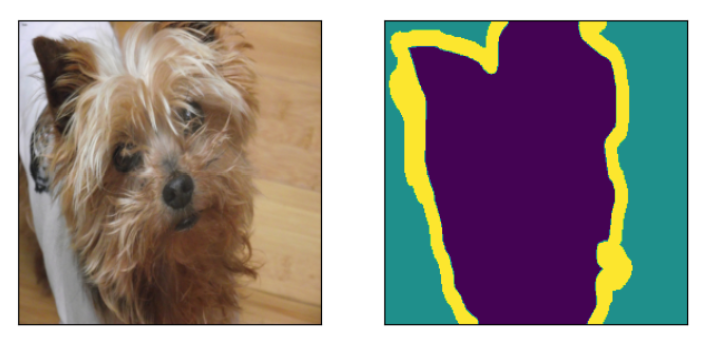



## Zadanie 0

Wczytaj zbiór OxfordIIIPet do zadania segmentacji, zbadaj co zawiera w środku oraz wyświetl przykładową maskę.

In [ ]:
# wczytaj zbiór z torchvision
# załaduj do DataLoadera (pamiętaj o podziale train, val, test)

# transform dla obrazów
transform_img = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# transform dla masek
def mask_to_tensor(mask):
    mask = np.array(mask)
    mask = mask - 1
    return torch.from_numpy(mask)

transform_mask = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(mask_to_tensor)
])
trainset = OxfordIIITPet(root="./data", target_types='segmentation', download=True, transform=transform_img, target_transform=transform_mask)
testset = OxfordIIITPet(root="./data", split='test', target_types='segmentation', download=True, transform=transform_img, target_transform=transform_mask)

batch_size = 16
train_size = int(0.8 * len(trainset))
train_data, val_data = torch.utils.data.random_split(trainset, [train_size, len(trainset) - train_size])

trainloader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
valloader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, num_workers=2, pin_memory=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, num_workers=2, pin_memory=True)

In [ ]:
print(trainset.classes)
print('Liczba klas:', len(trainset.classes))

['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']
Liczba klas: 37


In [1]:
import matplotlib.pyplot as plt

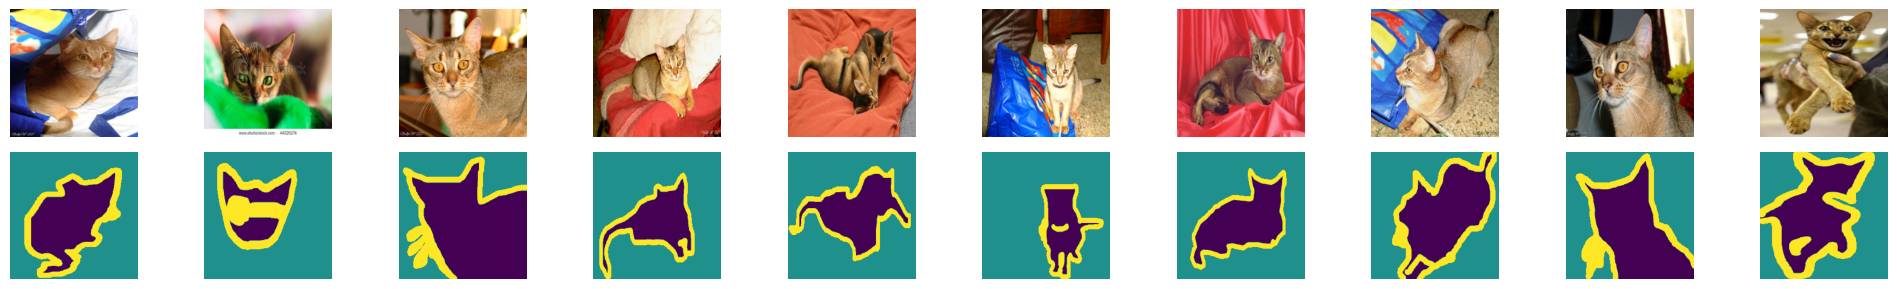

In [ ]:
plt.figure(figsize=(20, 3))
num_of_imgs = 10
for idx in range(num_of_imgs):
  plt.subplot(2, num_of_imgs, idx+1)
  plt.axis('off')
  img = trainset[idx][0]
  plt.tight_layout()
  plt.imshow(img.permute(1, 2, 0) * 0.5 + 0.5)

  plt.subplot(2, num_of_imgs, idx+1+num_of_imgs)
  plt.axis('off')
  img = trainset[idx][1]
  plt.tight_layout()
  plt.imshow(img)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## U-Net

Jest to popularna architektura która ma swój początek w zadaniu **segmentacji** biomedycznej. Do tej pory mieliśmy styczność z klasyfikacją, gdzie każdemu obrazkowi przypisywaliśmy kategorię, natomiast segmentacja polega na przypisaniu każdemu pikselowi kategorii.

Architektura składa się z enkodera i dekodera, pośredniej warstwy bottlenecka i połączeń typu skip (aka' pomost). Sieć enkodera jest klasyczną siecią konwolucyjną, w której zwiększa się liczba kanałów kosztem zmniejszenia rozdzielczości mapy. Sieć dekodera składa się z warstw *dekonwolucji*, które mają w przeciwieństwie do zwykłej konwolucji zwiększać rozdzielczość obrazka i zmniejszać liczbę kanałów. Dzięki temu końcowy wynik ma taki sam rozmiar jak wejściowy obrazek, co reprezentuje przypisanie klasy per piksel. Połączenia pomostowe służą do konkatenacji map z enkodera i dekodera, a celem jest zachowanie informacji na temat tego "co" i "gdzie" się znajduje. Dobre wytłumaczenie znajduje się [tutaj](https://www.kaggle.com/code/akshitsharma1/unet-architecture-explained-in-one-shot-tutorial).

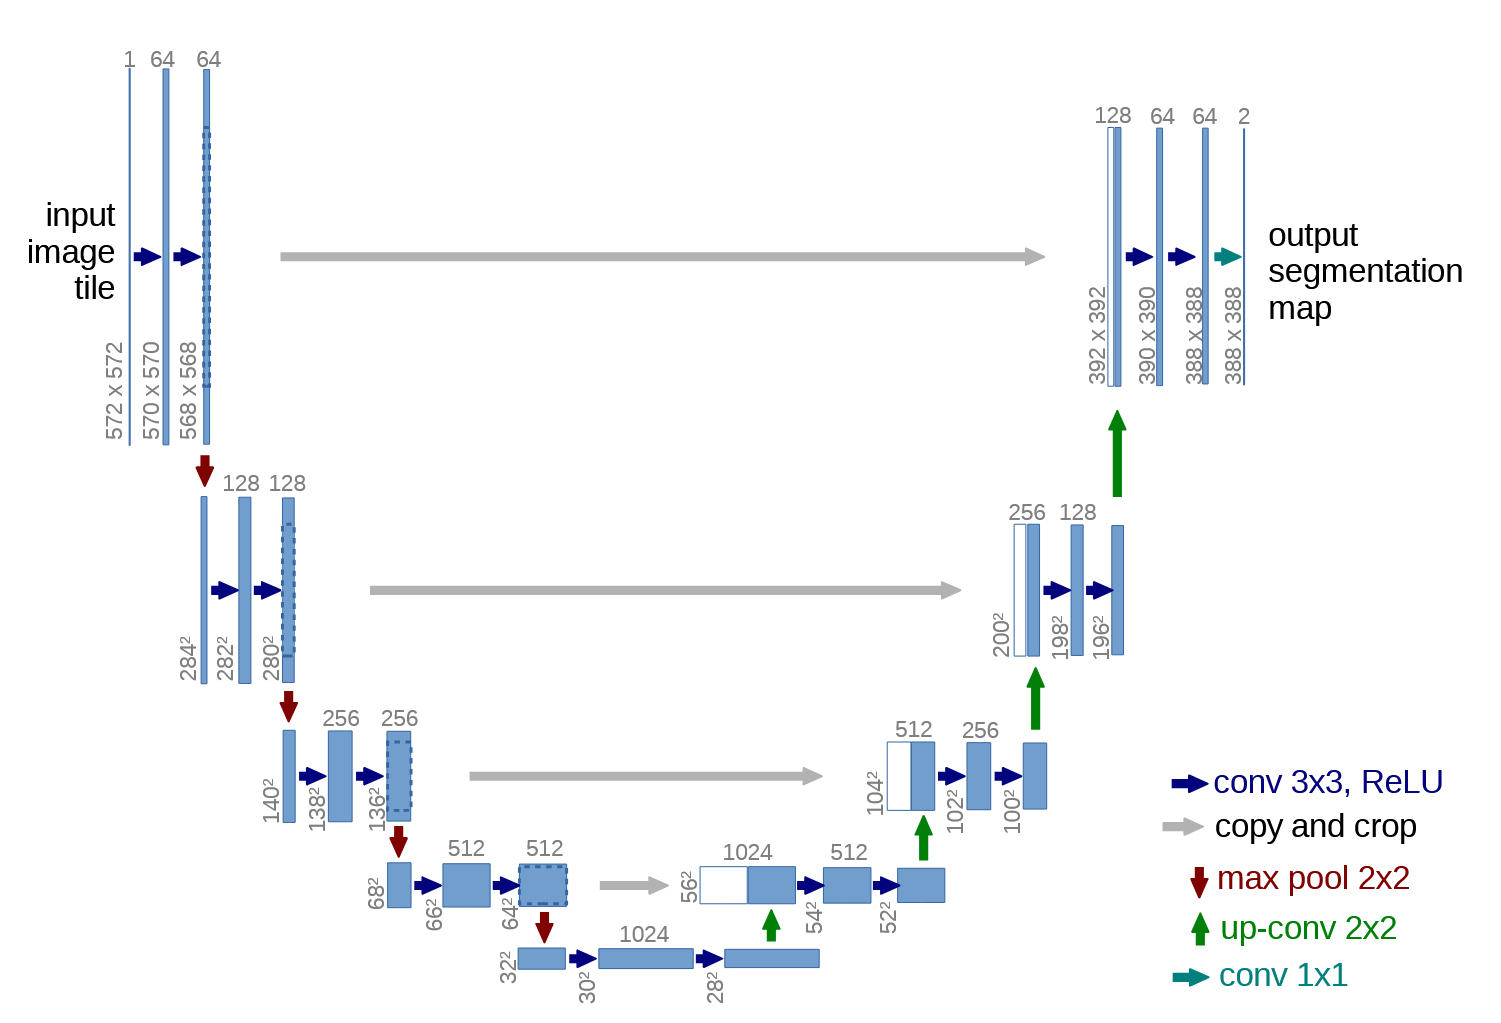

## Dekonwolucja

Dekonwolucja jest bratnią operacją konwolucji, ale jak już było wspomnianie, jej celem jest zwiększenie wymiarów przestrzennych. Składa się ona z kroków
- Upsampling: zwiększenie rozmiaru mapy zwykle dodając "puste" wiersze i kolumny
- Convolution: warstwa konwolucyjna (logiczne - czegoś też chcemy się nauczyć)
- Stride: $> 1$ zwiększa wymiar przestrzenny mapy
- Padding: to samo co w zwykłej konwolucji
- Activation: funkcja aktywacji (nieliniowa!, zwykle ReLU)

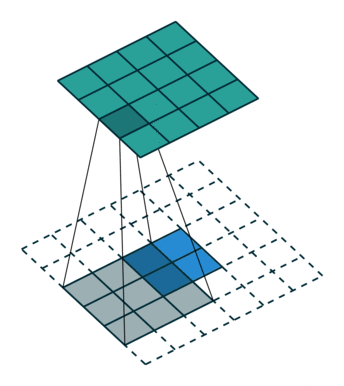

## Zadanie 1.1
Zaimplementuj blok warstwy enkodera, który będzie wykonywał m.in. operację konwolucji (zmniejszanie wymiary przestrzennego) oraz max-pooling. Jedną pułapką jest tutaj fakt, że enkoder musi zwracać dwie rzeczy - $x_{skip}$ jako wejście do dekodera, oraz $x_{down}$ po warstwie poolingu do dalszej warstwy enkodera.

$x_{skip} = ConvBlock(x)$

$x_{down} = MaxPool(x_{skip})$

gdzie $ConvBlock$ stanowi pipeline *konwolucja, batch-normalization, aktywacja* powtórzone $M$ razy (może być raz). Jest on już zaimplementowany niżej jako ```DoubleConv``` - możesz go dostosować do swoich potrzeb lub zostawić jak jest.

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, hidden_channels: int = None):
        super().__init__()

        if not hidden_channels:
            hidden_channels = out_channels

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(hidden_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [ ]:
class DownBlock(nn.Module): # blok budulcowy enkodera

  def __init__(self, in_channels: int, out_channels: int, hidden_channels: int = None): # dodaj parametry
    super().__init__()
    self.conv = DoubleConv(in_channels, out_channels, hidden_channels)
    self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)

  def forward(self, x): # dodaj parametry
    x_skip = self.conv(x)
    x_down = self.maxpool(x_skip)
    return x_skip, x_down

## Zadanie 1.2
Zaimplementuj *blok* warstwy dekodera, która będzie wykonywała operację dekonwolucji oraz konkatenacji cech z enkodera. Przetwarzanie powinno być według schematu:

*$x_{up} = ConvTranspose(x)$

$x_{cat} = Concat(x_{up}, s)$

$y = ConvBlock(x_{out})$

Nowa warstwa dekonwolucji jest zaimplementowana w torchu [ConvTranspose2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html). Należy zwrócić uwagę na **zgodność kształtów** oraz **liczbę kanałów** (szczególnie po konkatenacji!).

*alternatywnie można użyć warswty [Upsamplingu](https://docs.pytorch.org/docs/stable/generated/torch.nn.Upsample.html) + konwolucji

In [ ]:
class UpBlock(nn.Module): # blok budulcowy dekodera

  def __init__(self, in_channels: int, out_channels: int, hidden_channels: int = None): # dodaj parametry
    super().__init__()
    self.convtrans = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

    self.conv_with_skip = DoubleConv(out_channels+out_channels, out_channels, hidden_channels) # wersja do uneta
    self.conv_without_skip = DoubleConv(out_channels, out_channels, hidden_channels) # wersja do autoenkodera

  def forward(self, x, s=None): # dodaj parametry
    x_up = self.convtrans(x)

    if s is None:
      x = self.conv_without_skip(x_up)
    else:
      x_cat = torch.cat((x_up, s), dim=1)
      x = self.conv_with_skip(x_cat)
    return x

Zalecam zrobienie krótkiego sanity-check aby sprawdzić, czy dwa bloki łączą się poprawnie

In [ ]:
x = torch.randn(1, 3, 128, 128)
down_block = DownBlock(in_channels=3, out_channels=64) # dodaj argumenty
up_block = UpBlock(in_channels=64, out_channels=64) # dodaj argumenty

x_skip, x_down = down_block(x)
x_up = up_block(x_down, x_skip)

print(x_skip.shape, x_down.shape, x_up.shape)

torch.Size([1, 64, 128, 128]) torch.Size([1, 64, 64, 64]) torch.Size([1, 64, 128, 128])


## Zadanie 2.1
Następnym zadaniem jest wykorzystanie bloków do implementacji pełnej sieci. Niech nasza sieć składa się z N bloków enkodera $(E1​...En​)$, jednego bottlenecku $(B)$ i N bloków dekodera $(Dn​...D1​)$. Schemat będzie miał postać:

#### Enkoder
1. $(x1​,s1​)=E1​(input)$
2. $(x2​,s2​)=E2​(x1​)$
3. $(x3​,s3​)=E3​(x2​)$
4. $(x4​,s4​)=E4​(x3​)$

#### Bottleneck
5. $b=B(x4​)$ (zwykły blok konwolucyjny)

#### Dekoder
6. $d4​=D4​(b,s4​)$
7. $d3​=D3​(d4​,s3​)$
8. $d2​=D2​(d3​,s2​)$
9. $d1​=D1​(d2​,s1​)$

#### Spłaszczenie wyjścia
10. $output=Conv_{1x1}(d1​)$ --> wykorzystuje konwolucję $1x1$ do pozbycia się wymiaru kanału. Otrzymujemy tutaj $H \times W \times K$ predykcji (bo dla każdego piksela) i każdej klasy.

Wskazówki
- Rozmiar wejściowy: Musi być podzielny przez $2^{liczba poziomów}$ (dlaczego?), najlepiej używać potęg dwójki typu 256, 512
- Padding: równy 1
- Liczba kanałów: w enkoderze podwajamy $64 → 128 → 256$, w dekoderze dzielimy przez dwa $256 → 128 → 64$
- Konkatenacja: po wymiarze kanałów
- Wyjście: musi być takiego samo wymiary przestrzennego jak wejście, a liczba kanałów będzie odpowiadać liczbie klas.

In [ ]:
class UNet(nn.Module):

  def __init__(self, first_block_in_ftrs=3, first_block_out_ftrs=64, n_classes=3):
    super().__init__()
    # enkoder
    self.e1 = DownBlock(first_block_in_ftrs, first_block_out_ftrs)
    self.e2 = DownBlock(first_block_out_ftrs, first_block_out_ftrs*2)
    self.e3 = DownBlock(first_block_out_ftrs*2, first_block_out_ftrs*4)
    self.e4 = DownBlock(first_block_out_ftrs*4, first_block_out_ftrs*8)
    # bottleneck
    self.b = DoubleConv(first_block_out_ftrs*8, first_block_out_ftrs*16)
    # dekoder
    self.d4 = UpBlock(first_block_out_ftrs*16, first_block_out_ftrs*8)
    self.d3 = UpBlock(first_block_out_ftrs*8, first_block_out_ftrs*4)
    self.d2 = UpBlock(first_block_out_ftrs*4, first_block_out_ftrs*2)
    self.d1 = UpBlock(first_block_out_ftrs*2, first_block_out_ftrs)
    # output
    self.out = nn.Conv2d(first_block_out_ftrs, n_classes, kernel_size=1)

  def forward(self, x):
    s1, x = self.e1(x)
    s2, x = self.e2(x)
    s3, x = self.e3(x)
    s4, x = self.e4(x)
    x = self.b(x)
    x = self.d4(x, s4)
    x = self.d3(x, s3)
    x = self.d2(x, s2)
    x = self.d1(x, s1)
    return self.out(x)

## Zadanie 2.2
Kolejnym krokiem jest wyuczenie sieci do zadania segmentacji. Wykorzystaj ```nn.CrossEntropyLoss``` jako funkcję straty (lub posłuż się bardziej dostosowanymi metrykami jak [Dice Loss](https://smp.readthedocs.io/en/latest/losses.html#diceloss) jeśli uczenie będzie szło bardzo źle). W tym celu konieczne będzie spłaszczenie wyniku $B \times W \times H \times K$ do $B \times (WH) \times K$. Wyświetl krzywą uczenia oraz dokładność dla każdej klasy. Dodatkowo zbieraj co $M$ epok przykładowe predykcje (dla zbioru walidacyjnego) i wyświetl jak w trakcie trenowania zmieniała się maska segmentacji (najlepiej zostaw dataloder dla zbioru val z ```shuffle=False```)

---
Poniżej zawarty jest nieco zmodyfikowany kod treningowy, który wykorzystywałem w poprzednich notatnikach (moduł Helper_module.py). W zależności od ustawienia parametru `unet_training` uruchomiony zostanie kod do treningu uneta lub do autoenkodera (następne zadanko)

In [ ]:
import pandas as pd
import torch
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from tqdm import tqdm

class TrainingClass:
  def __init__(self, model, device, loss_fn, optimizer, early_stopping=True, scheduler=None, patience=15, lr_patience=5, target_names=None, val_prediction_interval=5, unet_training=True):
    super().__init__()
    self.model = model.to(device, non_blocking=True)
    self.patience = patience
    self.lr_patience = lr_patience
    self.loss_fn = loss_fn
    self.optimizer = optimizer
    self.device = device
    self.early_stopping = early_stopping
    self.scheduler = scheduler
    self.target_names = target_names
    self.val_prediction_interval = val_prediction_interval
    self.unet_training = unet_training

  def training_loop(self, epochs, model_name, trainloader, validationloader, testloader):
    training_losses = []
    validation_losses = []
    train_metrics = []
    validation_metrics = []
    training_accuracies = []
    validation_accuracies = []
    validation_examples = []

    best_loss = float('inf')
    wait = 0
    lr_wait = 0
    for epoch in tqdm(range(epochs)):
      self.train(trainloader)
      train_loss, metrics, _ = self.evaluate(trainloader)
      training_losses.append(train_loss)
      if self.unet_training: # zwróc dataframe metryk tylko podczas treningu uneta
        train_df, train_acc = self.create_metrics_dataframe(metrics)
        training_accuracies.append(train_acc)
        train_metrics.append(train_df)

      return_prediction = (epoch % self.val_prediction_interval == 0) # BOOL do cyklicznego pobierania próbek walidacyjnych
      loss, metrics, examples = self.evaluate(validationloader, return_prediction)
      validation_losses.append(loss)
      validation_examples.append(examples)
      if self.unet_training: # zwróc dataframe metryk tylko podczas treningu uneta
        val_df, val_acc = self.create_metrics_dataframe(metrics)
        validation_accuracies.append(val_acc)
        validation_metrics.append(val_df)

      if self.scheduler is not None:
        self.scheduler.step()

      if loss < best_loss:
        best_loss = loss
        wait = 0
        lr_wait = 0
      else:
        wait += 1
        lr_wait += 1
        if lr_wait >= self.lr_patience:
          self.optimizer.param_groups[0]['lr'] /= 2
          lr_wait = 0

        if self.early_stopping and wait >= self.patience:
          break

      if epoch % 1 == 0:
        if self.unet_training:
          print(f'epoch: {epoch+1}, train loss: {train_loss:.3f}, validation loss: {loss:.3f}, val acc: {val_acc:.3f}')
        else:
          print(f'epoch: {epoch+1}, train loss: {train_loss:.3f}, validation loss: {loss:.3f}')

    return _, training_losses, validation_losses, train_metrics, validation_metrics, training_accuracies, validation_accuracies, validation_examples

  def train(self, dataloader):
    self.model.train()
    for inputs, labels in dataloader:
      inputs = inputs.to(self.device)
      if self.unet_training: # etykiety dla uneta
        labels = labels.to(self.device).squeeze(1).long()
      else: # etykiety dla autoenkodera
        labels = inputs.clone().detach()

      self.optimizer.zero_grad()
      predictions = self.model(inputs)
      loss = self.loss_fn(predictions, labels)
      loss.backward()
      self.optimizer.step()

  def evaluate(self, dataloader, return_prediction=False):
    self.model.eval()
    all_labels = []
    all_predictions = []
    prediction_examples = []
    with torch.no_grad():
      total_loss = 0.0
      for inputs, labels in dataloader:
        inputs = inputs.to(self.device)
        if self.unet_training: # ewaluacja uneta
          labels = labels.to(self.device).squeeze(1).long()
          outputs = self.model(inputs)
          total_loss += self.loss_fn(outputs, labels).item()

          predicted = outputs.argmax(dim=1)
          if return_prediction:
            prediction_examples.append((inputs.cpu(), labels.cpu(), predicted.cpu()))
            return_prediction = False # zebranie tylko dla pierwszego batch'a aby pamięci nie przeciążyć xd
          all_labels.append(labels.view(-1))
          all_predictions.append(predicted.view(-1))
        else:                 # ewaluacja autoenkodera
          labels = inputs.clone().detach()

          outputs = self.model(inputs)
          total_loss += self.loss_fn(outputs, labels).item()

          if return_prediction:
            prediction_examples.append((inputs.cpu(), outputs.cpu()))
            return_prediction = False # zebranie tylko dla pierwszego batch'a aby pamięci nie przeciążyć xd

    if self.unet_training: # stworzenie raportu z metrykami tylko podczas treningu uneta
      all_labels = torch.cat(all_labels).cpu().numpy()
      all_predictions = torch.cat(all_predictions).cpu().numpy()
      report = classification_report(all_labels, all_predictions, target_names=self.target_names, zero_division=0, output_dict=True)
    else:
      report = []
    return total_loss / len(dataloader), report, prediction_examples

  # funkcja do przetworzenia classification_report z funkcji get_metrics do postaci DataFrame
  def create_metrics_dataframe(self, metrics):
    data = {}
    acc = metrics.pop('accuracy') # pobranie accuracy
    for key, value in metrics.items():
      # pobranie informacji o precision, recall, f1 per klasa
      if self.target_names is None or key in self.target_names:
        for k, v in value.items():
          if k != 'support':
            if k not in data:
              data[k] = {}
            data[k][key] = v
    df = pd.DataFrame.from_dict(data, orient='index')
    df.index.name = 'metric'
    return df, acc

# kod dla pojedynczego subplot
def plot_loss_and_accuracy(tr_list, val_list, function_name, plot_num=1, channels=''):
  plt.subplot(1, 2, plot_num)
  plt.title(f'Wykres {function_name}')
  plt.plot(tr_list, label=f'trening {channels}')
  plt.plot(val_list, label=f'walidacja {channels}')
  plt.xlabel('Epoka')
  plt.legend()
  plt.grid(True)

# utworzenie wizualizacji dla funkcji straty i accuracy
def create_loss_and_accuracy_plot(tr_losses=None, val_losses=None, tr_accuracies=None, val_accuracies=None, channels=''):
  if tr_losses and val_losses:
    plot_loss_and_accuracy(tr_losses, val_losses, 'funkcji straty', 1, channels)
  if tr_accuracies and val_accuracies:
    plot_loss_and_accuracy(tr_accuracies, val_accuracies, 'dokładności', 2, channels)


Trochę mała liczba epok, bo uczenie troszkę trwa, a już mi wcześniej przerwało sesję przy większej liczbie epok xd

In [ ]:
interval = 2
epochs_num = 10

In [ ]:
model = UNet()
optimizer = torch.optim.Adam(model.parameters(), weight_decay=0.0001)

trainer = TrainingClass(model, device, nn.CrossEntropyLoss(), optimizer, val_prediction_interval=interval)
ts_loss1, tr_losses1, val_losses1, tr_metrics1, val_metrics1, tr_accuracies1, val_accuracies1, val_examples1 = trainer.training_loop(epochs_num, "unet-1", trainloader, valloader, testloader)

 10%|█         | 1/10 [03:11<28:46, 191.87s/it]

epoch: 1, train loss: 0.612, validation loss: 0.623, val acc: 0.750


 20%|██        | 2/10 [06:35<26:30, 198.79s/it]

epoch: 2, train loss: 0.636, validation loss: 0.646, val acc: 0.727


 30%|███       | 3/10 [10:07<23:54, 204.90s/it]

...

epoch: 8, train loss: 0.394, validation loss: 0.421, val acc: 0.837


 90%|█████████ | 9/10 [31:03<03:28, 208.04s/it]

epoch: 9, train loss: 0.358, validation loss: 0.385, val acc: 0.851


100%|██████████| 10/10 [34:35<00:00, 207.53s/it]

epoch: 10, train loss: 0.403, validation loss: 0.441, val acc: 0.832


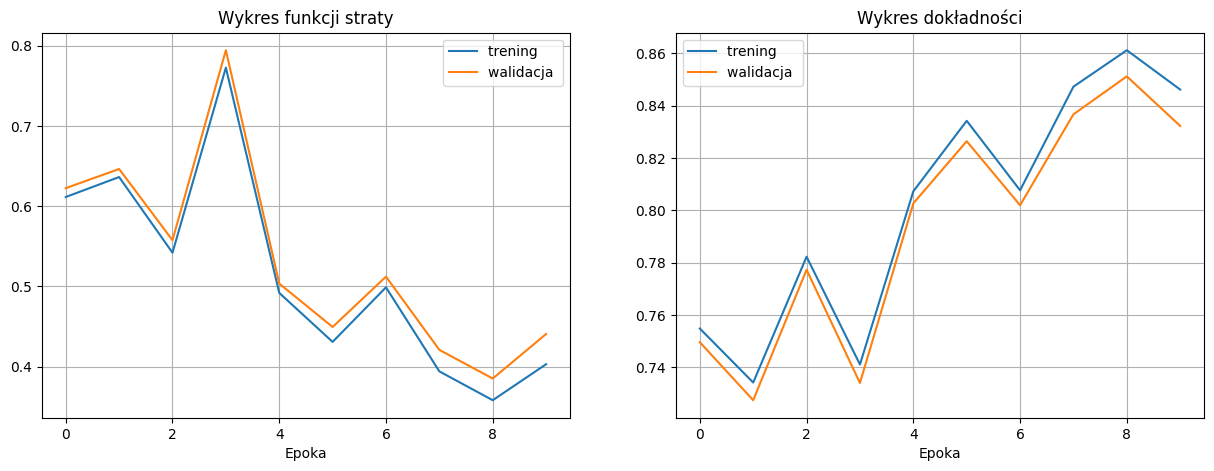

In [ ]:
plt.figure(figsize=(15, 5))
create_loss_and_accuracy_plot(tr_losses1, val_losses1, tr_accuracies1, val_accuracies1)
plt.show()

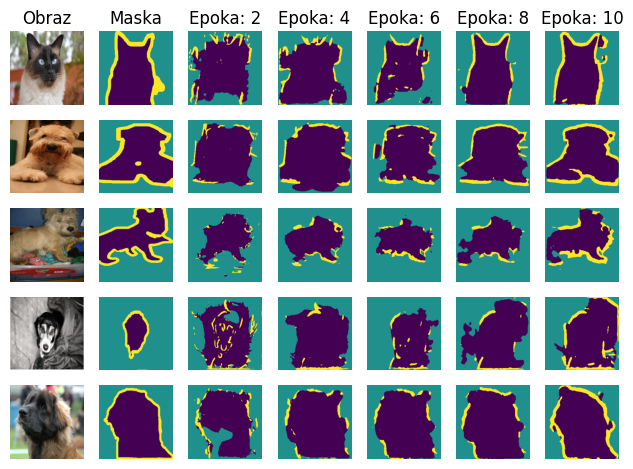

In [ ]:
def plot_examples_of_unet(examples, imgs_num=5):
  # zebranie tylko tych obrazów dla których zebrane są próbki walidacyjne
  examples = [ex[0] for ex in examples if len(ex) > 0]

  columns_num = len(examples) + 2
  for img_idx in range(imgs_num):
    # wyświetlenie oryginału
    ax_img = plt.subplot(imgs_num, columns_num, 1 + img_idx * columns_num)
    if img_idx == 0:
      ax_img.set_title('Obraz')
    img = examples[0][0][img_idx].cpu()
    ax_img.axis('off')
    ax_img.imshow(img.permute(1, 2, 0) * 0.5 + 0.5)
    plt.tight_layout()
    # wyświetlenie jego maski
    ax_img = plt.subplot(imgs_num, columns_num, 2 + img_idx * columns_num)
    if img_idx == 0:
      ax_img.set_title('Maska')
    img = examples[0][1][img_idx].cpu()
    ax_img.axis('off')
    ax_img.imshow(img)
    plt.tight_layout()

    # wyświetlenie wszystkich rekonstrukcji maski
    for epoch_idx, epoch_img in enumerate(examples):
      ax = plt.subplot(imgs_num, columns_num, 2 + img_idx * columns_num + epoch_idx + 1)
      if img_idx == 0:
        ax.set_title(f'Epoka: {interval * (epoch_idx + 1)}')
      ax.axis('off')
      img = epoch_img[2][img_idx].cpu()
      plt.tight_layout()
      ax.imshow(img)
  plt.show()

plot_examples_of_unet(val_examples1)

Wszystkie powyższe elementy (zarówno logi, wykres oraz wizualizacje masek) wskazują na trend do poprawy wyników - loss maleje a dokładność segmentacji rośnie. Wizualizacje masek dla przykładowych obrazów wizualnie potwierdzają te obserwacje.

## Autoenkoder

Autoenkoder to architektura zaliczana do uczenia nienadzorowanego (unsupervised learning), co oznacza, że trenujemy ją wyłącznie na danych wejściowych, bez udziału etykiet. Model ten składa się z połączonego enkodera i dekodera, a jego celem jest minimalizacja błędu rekonstrukcji wejścia (np. Mean Squared Error).

Matematycznie problem ten sprowadza się do znalezienia takiego zbioru parametrów θ, który minimalizuje funkcję straty: $$ L(x^{(t)}, g_{\theta}(f_{\theta}(x^{(t)}))) $$ dla *enkodera* $f$ i *dekodera* $g$. Kluczową cechą jest to, że wymiar na wyjściu enkodera jest zazwyczaj mniejszy niż danych wejściowych. Ma to na celu wymuszenie kompresji danych do tzw. przestrzeni ukrytej (latent space), co zapobiega nauczeniu się przez sieć trywialnej funkcji tożsamościowej. Dekoder zajmuje się następnie rekonstrukcją oryginalnego obrazu na podstawie tej skompresowanej reprezentacji.

Bardzo dobrą praktyką jest celowe zaszumianie danych wejściowych na etapie treningu. Działa to jak silna regularyzacja – enkoder musi wtedy nauczyć się ekstrahować najważniejsze, kluczowe cechy danych, aby być w stanie odtworzyć czysty sygnał. Tak wytrenowany autoenkoder znajduje zastosowanie głównie w tworzeniu zwartych osadzeń danych (embeddingów), które mogą zostać wykorzystane w dalszych etapach, np. w zadaniu klasyfikacji.

### Przepływ danych

1. Enkoder: zajmuje się kompresją wejściowego obrazu, zwykle do zmniejszania rozmiaru przestrzennego używamy $stride=2$ zamiast max-pooling.
2. Bottleneck: punkt największej kompresji, wykorzystuje znany już $AdaptiveAvgPool2d$ aby wymusić mały rozmiar przestrzenny (np. $2 \times 2$) do dekodowania
3. Dekoder: odbudowuje obraz z wykorzystaniem wcześniej omawianych transponowanych konwolucji.

### Funkcja straty
Wykorzystamy funkcję straty [MSE](https://docs.pytorch.org/docs/stable/generated/torch.nn.MSELoss.html#mseloss) do porównania obrazu wejściowego i zrekonstruowanego. Alternatywnie może być wykorzystane [MAE](https://docs.pytorch.org/docs/stable/generated/torch.nn.L1Loss.html) ponieważ jest mniej odporne na wartości odstające. Wartości obrazu powinny być znormalizowane, ale wyjścia sieci nie muszą być ograniczone.

## Zadanie 3.1

Zaimplementuj sieć autoenkoder. Będzie ona podobna do sieci U-Net, natomiast nie używa *skip connections* do połączenia dwóch części (ma prostszy schemat). Wyucz sieć traktując obraz wejściowy jako "labele" (pamiętamy, że jest to zadanie nienadzorowane, ale nadal potrzebujemy jakiegoś ground-truth). Wyświetl ciekawsze przykłady rekonstrukcji i zawrzyj wnioski na temat łatwości uczenia sieci i jakości zrekonstruowanych obrazów.

**Uwaga**: możecie wczytać zbiór danych do nauki na wszytkich $37$ klasach, lub tylko na klasach binarnych - dla **target_types=binary-category**. Nie ma to oczywiście znaczenia do nauki autoenkodera, ale w zadaniu 3.2 potrzebne są kategorie - być może lepiej będzie zwizualizować tylko jak przestrzeń się układa dla psów i kotów, niż dla każdej z 37 klas.

In [ ]:
class Encoder(nn.Module):

  def __init__(self, first_block_in_ftrs, first_block_out_ftrs):
    super().__init__()
    self.e1 = DownBlock(first_block_in_ftrs, first_block_out_ftrs)
    self.e2 = DownBlock(first_block_out_ftrs, first_block_out_ftrs*2)
    self.e3 = DownBlock(first_block_out_ftrs*2, first_block_out_ftrs*4)
    self.e4 = DownBlock(first_block_out_ftrs*4, first_block_out_ftrs*8)

  def forward(self, x):
    _, x = self.e1(x)
    _, x = self.e2(x)
    _, x = self.e3(x)
    _, x = self.e4(x)
    return x

In [ ]:
class Decoder(nn.Module):

  def __init__(self, bottleneck_channels, first_block_out_ftrs):
    super().__init__()
    self.d4 = UpBlock(bottleneck_channels, first_block_out_ftrs*8)
    self.d3 = UpBlock(first_block_out_ftrs*8, first_block_out_ftrs*4)
    self.d2 = UpBlock(first_block_out_ftrs*4, first_block_out_ftrs*2)
    self.d1 = UpBlock(first_block_out_ftrs*2, first_block_out_ftrs)

  def forward(self, x):
    x = self.d4(x)
    x = self.d3(x)
    x = self.d2(x)
    x = self.d1(x)
    return x

In [ ]:
class CNNAutoencoder(nn.Module): # łączymy tutaj logikę enkodera i dekodera
    def __init__(self, first_block_in_ftrs=3, first_block_out_ftrs=64, output_channels=3, bottleneck_channels=4):
        super().__init__()
        self.encoder = Encoder(first_block_in_ftrs, first_block_out_ftrs)
        self.bottleneck = DoubleConv(first_block_out_ftrs*8, bottleneck_channels)
        self.decoder = Decoder(bottleneck_channels, first_block_out_ftrs)
        self.out = nn.Conv2d(first_block_out_ftrs, output_channels, kernel_size=1)

    def forward(self, x):
        x = self.encoder(x)
        x = self.bottleneck(x)
        x = self.decoder(x)
        x = self.out(x)
        return x

    def embeddings(self, x):
      x = self.encoder(x)
      x = self.bottleneck(x)
      return torch.flatten(x, start_dim=1)

Załadowanie nowych danych pod nowy problem.

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
trainset = OxfordIIITPet(root="./data", target_types='binary-category', download=True, transform=transform)
testset = OxfordIIITPet(root="./data", split='test', target_types='binary-category', download=True, transform=transform)

batch_size = 16
train_size = int(0.8 * len(trainset))
train_data, val_data = torch.utils.data.random_split(trainset, [train_size, len(trainset) - train_size])

trainloader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
valloader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, num_workers=2, pin_memory=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, num_workers=2, pin_memory=True)

100%|██████████| 792M/792M [00:35<00:00, 22.0MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 11.7MB/s]


### Zadanie 3.2
Wyucz sieć autoeknkodera. Klasycznie loguj funkcję straty (czy będziesz logować accuracy??), oraz zbieraj rekonstrukcje dla zbioru walidacyjnego w trakcie uczenia i wyświetl jak się zmieniały w trakcie trenowania. Eksperymenty wykonaj dla różnej wielkości *bottlenecka* (np. $4, 16, 32$) i zapisz swoje obserwacje.

In [ ]:
interval = 2
epochs_num = 10

In [ ]:
model_ae = CNNAutoencoder()
optimizer = torch.optim.Adam(model_ae.parameters(), weight_decay=0.0001)

trainer = TrainingClass(model_ae, device, nn.MSELoss(), optimizer, val_prediction_interval=interval, unet_training=False)
ts_loss1, tr_losses1, val_losses1, _, _, _, _, val_examples1 = trainer.training_loop(epochs_num, "autoencoder-1", trainloader, valloader, testloader)

 10%|█         | 1/10 [01:59<17:54, 119.41s/it]

epoch: 1, train loss: 0.065, validation loss: 0.065


 20%|██        | 2/10 [04:08<16:39, 124.99s/it]

epoch: 2, train loss: 0.059, validation loss: 0.060


 30%|███       | 3/10 [06:20<14:57, 128.24s/it]

...

epoch: 8, train loss: 0.048, validation loss: 0.049


 90%|█████████ | 9/10 [19:16<02:09, 129.21s/it]

epoch: 9, train loss: 0.049, validation loss: 0.050


100%|██████████| 10/10 [21:25<00:00, 128.57s/it]

epoch: 10, train loss: 0.048, validation loss: 0.048


In [ ]:
model_ae2 = CNNAutoencoder(bottleneck_channels=8)
optimizer = torch.optim.Adam(model_ae2.parameters(), weight_decay=0.0001)

trainer = TrainingClass(model_ae2, device, nn.MSELoss(), optimizer, val_prediction_interval=interval, unet_training=False)
ts_loss2, tr_losses2, val_losses2, _, _, _, _, val_examples2 = trainer.training_loop(epochs_num, "autoencoder-2", trainloader, valloader, testloader)

 10%|█         | 1/10 [02:09<19:24, 129.39s/it]

epoch: 1, train loss: 0.078, validation loss: 0.079


 20%|██        | 2/10 [04:18<17:12, 129.05s/it]

epoch: 2, train loss: 0.063, validation loss: 0.064


 30%|███       | 3/10 [06:27<15:04, 129.16s/it]

...

epoch: 8, train loss: 0.043, validation loss: 0.044


 90%|█████████ | 9/10 [19:22<02:09, 129.08s/it]

epoch: 9, train loss: 0.043, validation loss: 0.044


100%|██████████| 10/10 [21:31<00:00, 129.13s/it]

epoch: 10, train loss: 0.055, validation loss: 0.056


In [ ]:
model_ae3 = CNNAutoencoder(bottleneck_channels=16)
optimizer = torch.optim.Adam(model_ae3.parameters(), weight_decay=0.0001)

trainer = TrainingClass(model_ae3, device, nn.MSELoss(), optimizer, val_prediction_interval=interval, unet_training=False)
ts_loss3, tr_losses3, val_losses3, _, _, _, _, val_examples3 = trainer.training_loop(epochs_num, "autoencoder-3", trainloader, valloader, testloader)

 10%|█         | 1/10 [02:09<19:26, 129.62s/it]

epoch: 1, train loss: 0.074, validation loss: 0.076


 20%|██        | 2/10 [04:18<17:14, 129.36s/it]

epoch: 2, train loss: 0.060, validation loss: 0.060


 30%|███       | 3/10 [06:27<15:03, 129.09s/it]

...

epoch: 8, train loss: 0.040, validation loss: 0.040


 90%|█████████ | 9/10 [19:24<02:09, 129.31s/it]

epoch: 9, train loss: 0.055, validation loss: 0.055


100%|██████████| 10/10 [21:33<00:00, 129.31s/it]

epoch: 10, train loss: 0.073, validation loss: 0.074


In [ ]:
model_ae4 = CNNAutoencoder(bottleneck_channels=32)
optimizer = torch.optim.Adam(model_ae4.parameters(), weight_decay=0.0001)

trainer = TrainingClass(model_ae4, device, nn.MSELoss(), optimizer, val_prediction_interval=interval, unet_training=False)
ts_loss4, tr_losses4, val_losses4, _, _, _, _, val_examples4 = trainer.training_loop(epochs_num, "autoencoder-4", trainloader, valloader, testloader)

 10%|█         | 1/10 [02:08<19:20, 128.99s/it]

epoch: 1, train loss: 0.057, validation loss: 0.059


 20%|██        | 2/10 [04:18<17:14, 129.36s/it]

epoch: 2, train loss: 0.059, validation loss: 0.060


 30%|███       | 3/10 [06:27<15:05, 129.36s/it]

...

epoch: 8, train loss: 0.042, validation loss: 0.042


 90%|█████████ | 9/10 [19:23<02:09, 129.25s/it]

epoch: 9, train loss: 0.057, validation loss: 0.057


100%|██████████| 10/10 [21:32<00:00, 129.29s/it]

epoch: 10, train loss: 0.029, validation loss: 0.030


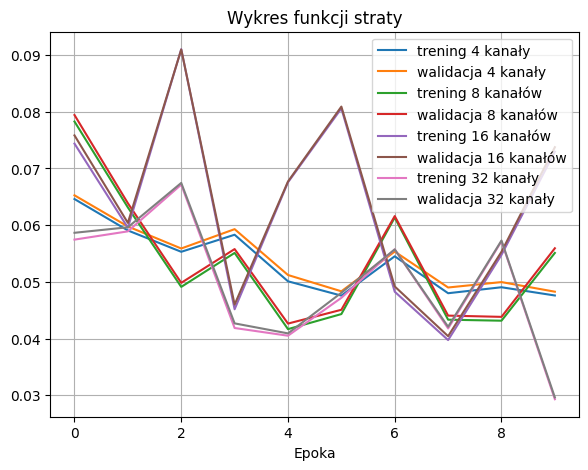

In [ ]:
plt.figure(figsize=(15, 5))
create_loss_and_accuracy_plot(tr_losses1, val_losses1, channels='4 kanały')
create_loss_and_accuracy_plot(tr_losses2, val_losses2, channels='8 kanałów')
create_loss_and_accuracy_plot(tr_losses3, val_losses3, channels='16 kanałów')
create_loss_and_accuracy_plot(tr_losses4, val_losses4, channels='32 kanały')
plt.show()

4 kanały bottleneck


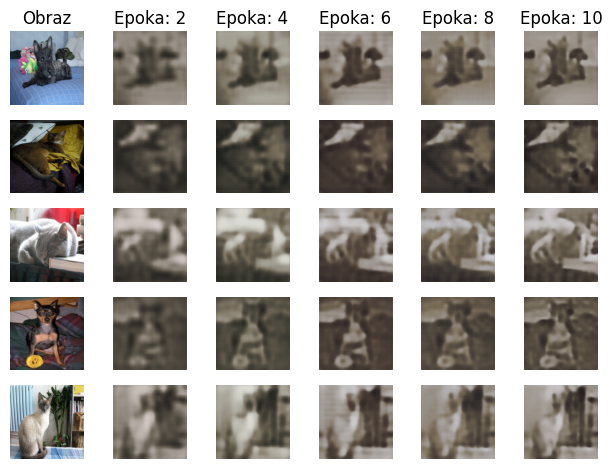

8 kanałów bottleneck


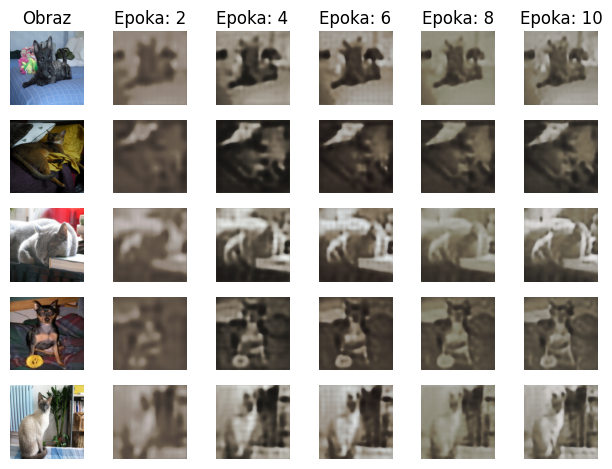

16 kanałów bottleneck


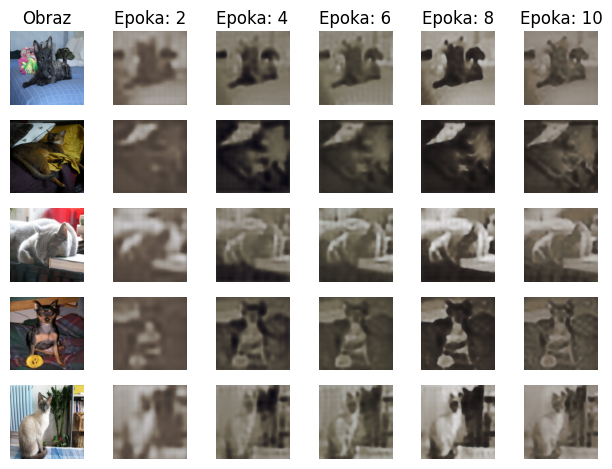

32 kanały bottleneck


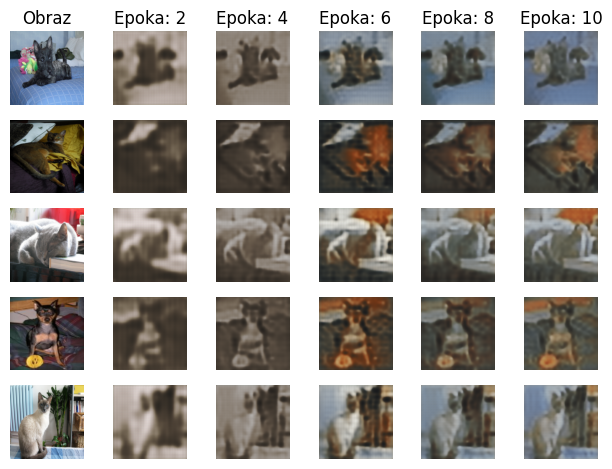

In [ ]:
def plot_examples_of_autoencoder(examples, imgs_num=5):
  examples = [ex[0] for ex in examples if len(ex) > 0]

  columns_num = len(examples) + 1
  for img_idx in range(imgs_num):
    # wyświetlenie oryginału
    ax_img = plt.subplot(imgs_num, columns_num, 1 + img_idx * columns_num)
    if img_idx == 0:
      ax_img.set_title('Obraz')
    img = examples[0][0][img_idx].cpu()
    ax_img.axis('off')
    ax_img.imshow(img.permute(1, 2, 0) * 0.5 + 0.5)
    plt.tight_layout()

    # wyświetlenie jego wszystkich rekonstrukcji
    for epoch_idx, epoch_img in enumerate(examples):
      ax = plt.subplot(imgs_num, columns_num, 1 + img_idx * columns_num + epoch_idx + 1)
      if img_idx == 0:
        ax.set_title(f'Epoka: {interval * (epoch_idx + 1)}')
      ax.axis('off')
      img = epoch_img[1][img_idx].cpu()
      plt.tight_layout()
      ax.imshow(img.permute(1, 2, 0) * 0.39 + 0.46)
  plt.show()
print("4 kanały bottleneck")
plot_examples_of_autoencoder(val_examples1)
print("8 kanałów bottleneck")
plot_examples_of_autoencoder(val_examples2)
print("16 kanałów bottleneck")
plot_examples_of_autoencoder(val_examples3)
print("32 kanały bottleneck")
plot_examples_of_autoencoder(val_examples4)

Powyższe wizualizacje pokazują jak autoenkoder uczy się odbudowywać obrazy. Choć na wykresie modele z różną liczbą kanałów bottleneck niewiele się od siebie różnią, to wizualizacja przykładowych obrazów pokazują, że model z największą liczbą kanałów bottleneck najlepiej odbudowuje obrazy, szczególnie ich barwę. Modele z mniejszym bottleneck natomiast mają tendecję do odtworzenia jasności pikseli, pomijając ich barwę.

## *Zadanie 3.3
Zwizualizuj wektor osadzeń przy pomocy *T-SNE*. Do tego celu potrzeba będzie spłaszczyć mapę powstałą w wyniku przejścia przez enkoder. Nie jest tutaj potrzebna sieć dekodera. Zwróć uwagę na to, czy klasy są wizualnie dobrze rozdzielone.

In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

Do tego zadania wykorzystałem ostatni model, jako że osiągnął on najmniejszy loss oraz wizualne wyniki były najbardziej satysfakcjonujące.

In [ ]:
model_ae4.eval()
with torch.inference_mode():
   features = []
   for i,(data, _) in enumerate(testloader):
       data = data.to(device)
       features.append(model_ae4.embeddings(data).cpu().numpy())
features = np.concatenate(features, axis=0)

tsne = TSNE(metric='cosine')
tsne_features = tsne.fit_transform(features)

In [ ]:
labels = torch.cat([y for _, y in testloader]).cpu().numpy()

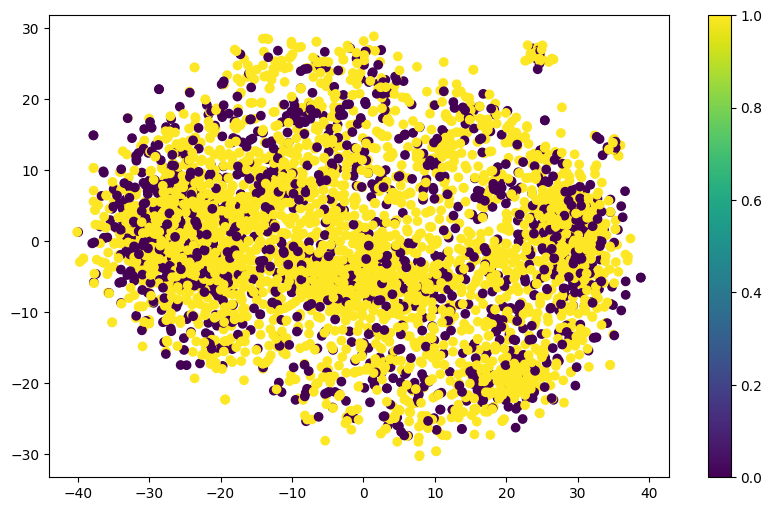

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(tsne_features[:, 0], tsne_features[:, 1], c=labels, cmap='viridis')
plt.colorbar()
plt.show()

Aktualny model nie rozdziela za dobrze obu klas (żółte - psy, fioletowe - koty). Zmiana różnych parametrów w TSNE również nie pomogła, więc spróbuję nieco dotrenować model.

In [ ]:
from torch.optim.lr_scheduler import CosineAnnealingLR

In [ ]:
interval = 2
epochs_num = 25

In [ ]:
model_ae5 = CNNAutoencoder(bottleneck_channels=32)
optimizer = torch.optim.Adam(model_ae5.parameters(), weight_decay=0.0001)
scheduler = CosineAnnealingLR(optimizer, T_max=epochs_num, eta_min=0.0001)

trainer = TrainingClass(model_ae5, device, nn.MSELoss(), optimizer, val_prediction_interval=interval, scheduler=scheduler, unet_training=False)
ts_loss5, tr_losses5, val_losses5, _, _, _, _, val_examples5 = trainer.training_loop(epochs_num, "autoencoder-5", trainloader, valloader, testloader)

  4%|▍         | 1/25 [02:08<51:29, 128.71s/it]

epoch: 1, train loss: 0.106, validation loss: 0.106


  8%|▊         | 2/25 [04:18<49:29, 129.09s/it]

epoch: 2, train loss: 0.067, validation loss: 0.067


 12%|█▏        | 3/25 [06:27<47:25, 129.32s/it]

...

epoch: 23, train loss: 0.023, validation loss: 0.023


 96%|█████████▌| 24/25 [51:36<02:08, 128.07s/it]

epoch: 24, train loss: 0.022, validation loss: 0.023


100%|██████████| 25/25 [53:44<00:00, 128.98s/it]

epoch: 25, train loss: 0.019, validation loss: 0.019


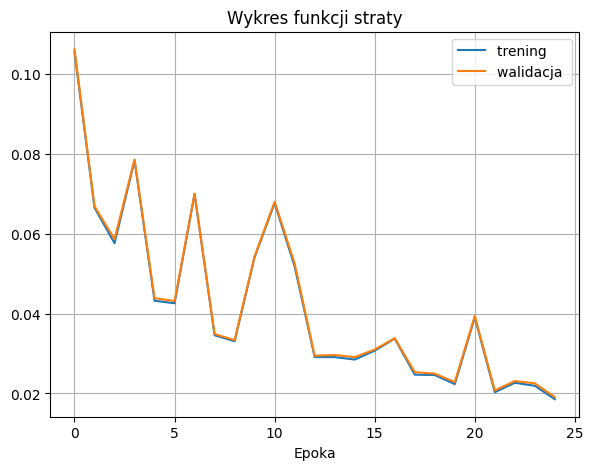

In [ ]:
plt.figure(figsize=(15, 5))
create_loss_and_accuracy_plot(tr_losses5, val_losses5)
plt.show()

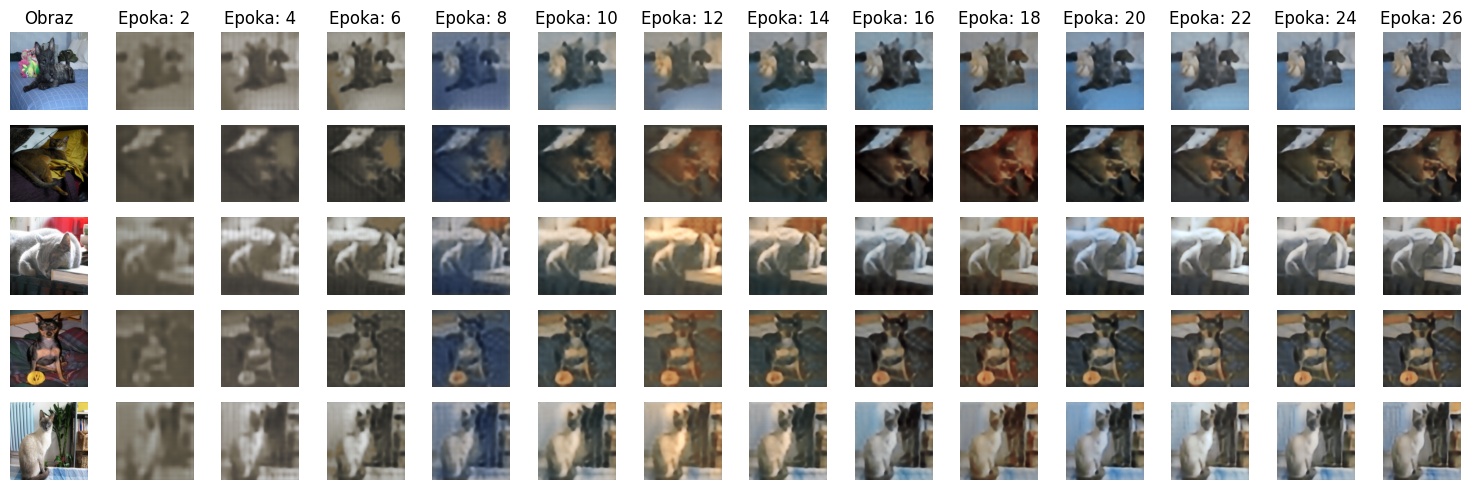

In [ ]:
plt.figure(figsize=(15, 5))
plot_examples_of_autoencoder(val_examples5)

Dłuższy trening z dodatkowo schedulerem poprawił wyniki co widać zarówno po mniejszym loss jak i wizualnych przykładach obrazów.

In [ ]:
model_ae5.eval()
with torch.inference_mode():
   features = []
   for i,(data, _) in enumerate(testloader):
       data = data.to(device)
       features.append(model_ae5.embeddings(data).cpu().numpy())
features = np.concatenate(features, axis=0)

tsne = TSNE(metric='cosine')
tsne_features = tsne.fit_transform(features)

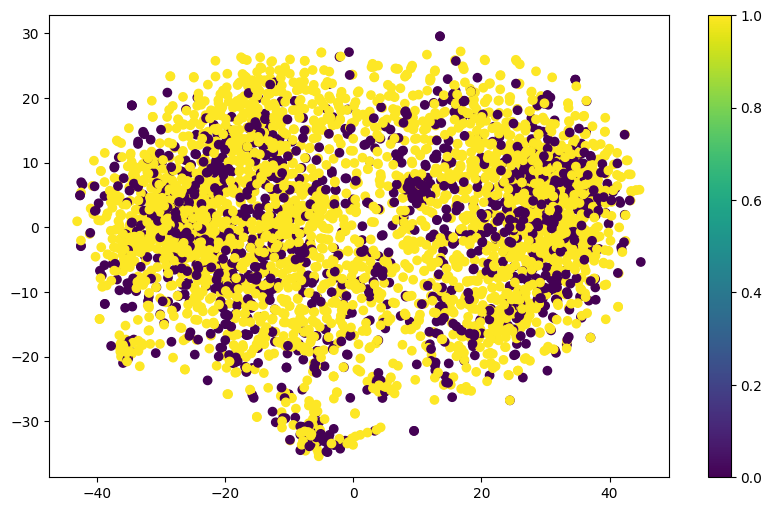

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(tsne_features[:, 0], tsne_features[:, 1], c=labels, cmap='viridis')
plt.colorbar()
plt.show()

Wizualizacja TSNE na dotrenowanym modelu wciąż zwraca dość losową chmurę punktów, aczkolwiek pionowo przez środek przechodzi pewna granica, gdzie zagęszczenie punktów jest mniejsze, więc wygląda na to, że model próbuje wyekstrahować pewne cechy, które jednak nie pokrywają się z klasami.